In [1]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import h5py

def plot_3d_point_clouds(features, material='W', figsize=(10, 8), energy_cmap="viridis", s=5):
    """
    3D scatter comparison of real and generated point clouds.

    real_features, gen_features: awkward arrays or dict-like with fields 'x','y','z','energy'
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3d)
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    features = features[0]

    # flatten and convert to numpy
    x = ak.flatten(features["x"]).to_numpy()
    y = ak.flatten(features["y"]).to_numpy()
    z = ak.flatten(features["z"]).to_numpy()
    e = ak.flatten(features["energy"]).to_numpy()


    # optional: filter very small-energy voxels
    mask_r = e > 0.01

    sc = ax.scatter(x[mask_r], y[mask_r], z[mask_r], c=e[mask_r], cmap=energy_cmap, s=s, alpha=0.6, label=material)
    #sc_g = ax.scatter(xg[mask_g], yg[mask_g], zg[mask_g], c=eg[mask_g], cmap=energy_cmap, s=s, alpha=0.6, marker="^", label="gen")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()
    fig.colorbar(sc, ax=ax, shrink=0.5, label="Energy")
    return fig, ax

In [5]:
file_path = "Generations/W_Ta_GPT_Generations.h5"
with h5py.File(file_path,"r") as h5file:
    print(h5file.keys())
    print(h5file['showers'][0])

<KeysViewHDF5 ['showers']>
(14.659303, array([    0,  1726,  2233, ..., 27001, 27001, 27001], dtype=uint16), array([    0,    94,   164, ..., 24939, 24939, 24939], dtype=uint16), 0)


In [3]:
def read_shower_file(filepath, n_load=None, chunk_size=1000):
    with h5py.File(filepath, "r") as h5file:
        # print(h5file.keys())
        # print(h5file['30x30'].keys())
        # print(h5file['30x30']['layers'])
        dataset_showers = h5file["30x30"]['layers'][()]
        dataset_showers_e = h5file['30x30']['energy'][()]
        print(dataset_showers.shape)
        print(dataset_showers_e.shape)
        total_showers = dataset_showers.shape[0]

    return dataset_showers,dataset_showers_e

    #     if n_load is None:
    #         n_load = total_showers

    #     data_dict = {
    #         "x": [],
    #         "y": [],
    #         "z": [],
    #         "energy": [],
    #     }

    #     for start in range(0, n_load, chunk_size):
    #         end = min(start + chunk_size, n_load)
    #         table = dataset_showers[start:end]

    #         data_dict["z"].append(table[:, :, 0])
    #         data_dict["x"].append(table[:, :, 1])
    #         data_dict["y"].append(table[:, :, 2])
    #         data_dict["energy"].append(table[:, :, 3])

    # # Concatenate chunks
    # data_dict = {key: ak.concatenate(value) for key, value in data_dict.items()}
    # ak_array = ak.Array(data_dict)
    # return ak_array

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize


def plot_shower(voxels,material="G4_W"):
    # Fixed colormap scale: 0 to 50 MeV
    vmin, vmax = 0.1, 2
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    # Map energy -> RGBA colors
    colors = cm.viridis(norm(voxels))
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot voxels
    ax.voxels(voxels, facecolors=colors, edgecolor='k', linewidth=0.1)
    
    ax.set_xlabel("Z")
    ax.set_ylabel("X")
    ax.set_zlabel("Y")
    
    # ---------- Add a colorbar ----------
    mappable = cm.ScalarMappable(norm=norm, cmap=cm.viridis)
    mappable.set_array([])  # needed for matplotlib
    cbar = plt.colorbar(mappable, ax=ax, shrink=0.6)
    cbar.set_label("Energy (MeV)", fontsize=12)
    plt.title(material,fontsize=25)
    ax.view_init(elev=15,azim=-65)
    
    #plt.tight_layout()
    plt.show()

(888, 30, 30, 30)
(888, 1)


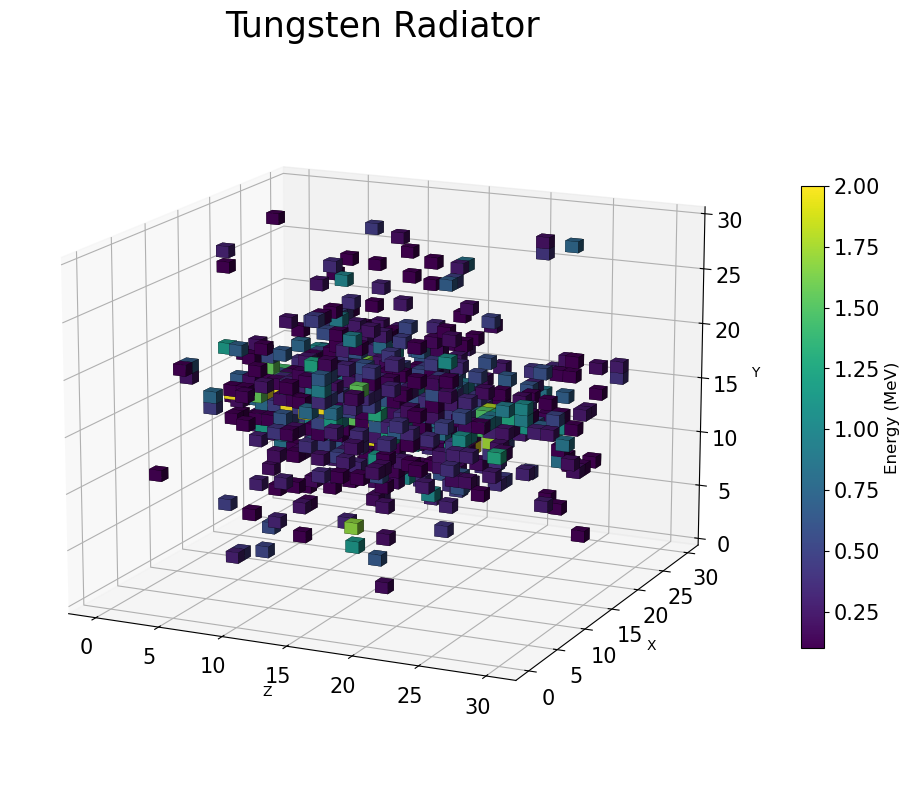

In [29]:

data_path = "../W_simulation_50GeV/processed/photon-shower-4_corrected.hdf5"
showers,energy = read_shower_file(data_path)

i = 0
voxels = showers[i]

plot_shower(voxels,"Tungsten Radiator")

(885, 30, 30, 30)
(885, 1)


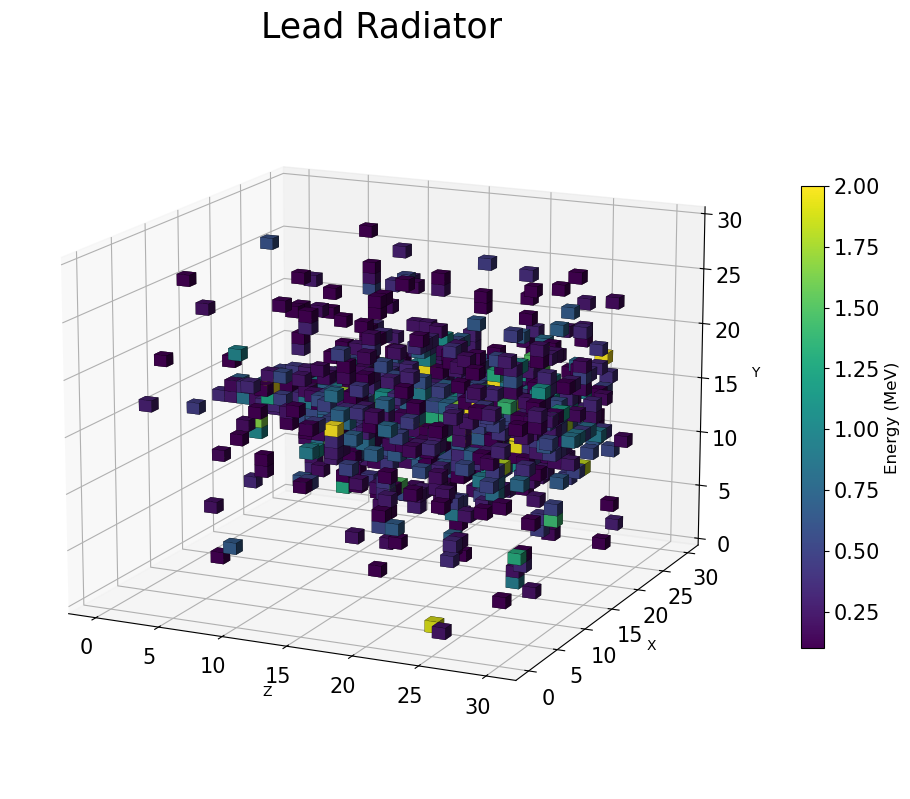

In [28]:
data_path = "../Pb_simulation_50GeV/processed/photon-shower-4_corrected.hdf5"
showers,energy = read_shower_file(data_path)

i = 0
voxels = showers[i]

plot_shower(voxels,"Lead Radiator")

# Histogram Level

In [78]:
def read_shower_file(filepath, n_load=None, chunk_size=1000):
    with h5py.File(filepath, "r") as h5file:
       # print(h5file.keys())
        #print(h5file[0])
        # print(h5file['30x30'].keys())
        # print(h5file['30x30']['layers'])
        dataset_showers = h5file["30x30"]['layers']#[()]
        dataset_showers_e = h5file['30x30']['energy']#[()]
        print(dataset_showers.shape)
        print(dataset_showers_e.shape)
        total_showers = dataset_showers.shape[0]

        if n_load is None:
            n_load = total_showers

        data_dict = {
            "x": [],
            "y": [],
            "z": [],
            "energy": [],
        }

        for start in range(0, n_load, chunk_size):
            end = min(start + chunk_size, n_load)
            table = dataset_showers[start:end]
            print('table',table.shape)

            # table: (B, X, Y, Z)
            for tab in table:      
                x, y, z = np.nonzero(tab)
            
                E = tab[x, y, z]
    
                #data_dict["z"].append(x)
                #data_dict["x"].append(y)
                #data_dict["y"].append(z)
                data_dict["energy"].append(E)

        ak_array = ak.Array(data_dict)

    def convert_to_list_of_dict(ak_array):
        list_of_dict = []
        for i in range(len(ak_array)):
            data = ak_array[i]
            dict_ = {"x":data['x'],"y":data['y'],'z':data['z'],'energy':data['energy']}
            list_of_dict.append(dict_)
        return list_of_dict   
    
    return ak_array

TypeError: Accessing a group is done with bytes or str, not <class 'int'>

In [5]:
#data_path = "../Pb_simulation_50GeV/processed/photon-shower-4_corrected.hdf5"
data_path = "data/PlottingFiles/Pb/photon-shower-3_corrected.hdf5"
G4_Pb = read_shower_file(data_path)


#data_path = "../W_simulation_50GeV/processed/photon-shower-4_corrected.hdf5"
data_path = "data/PlottingFiles/W/photon-shower-3_corrected.hdf5"
G4_W = read_shower_file(data_path)

(9621, 30, 30, 30)
(9621, 1)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (621, 30, 30, 30)
(9681, 30, 30, 30)
(9681, 1)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (681, 30, 30, 30)


In [2]:
from plotting import plot_paper_plots, plot_compare_gen_showers
from gabbro.utils.utils import get_COG_ak

/mnt/c/Users/James/FM4Design/FM4CAL/gabbro/plotting/utils.py:528: RuntimeWarning: divide by zero encountered in scalar divide
  ratios.append(counts2[j] / counts1[j])


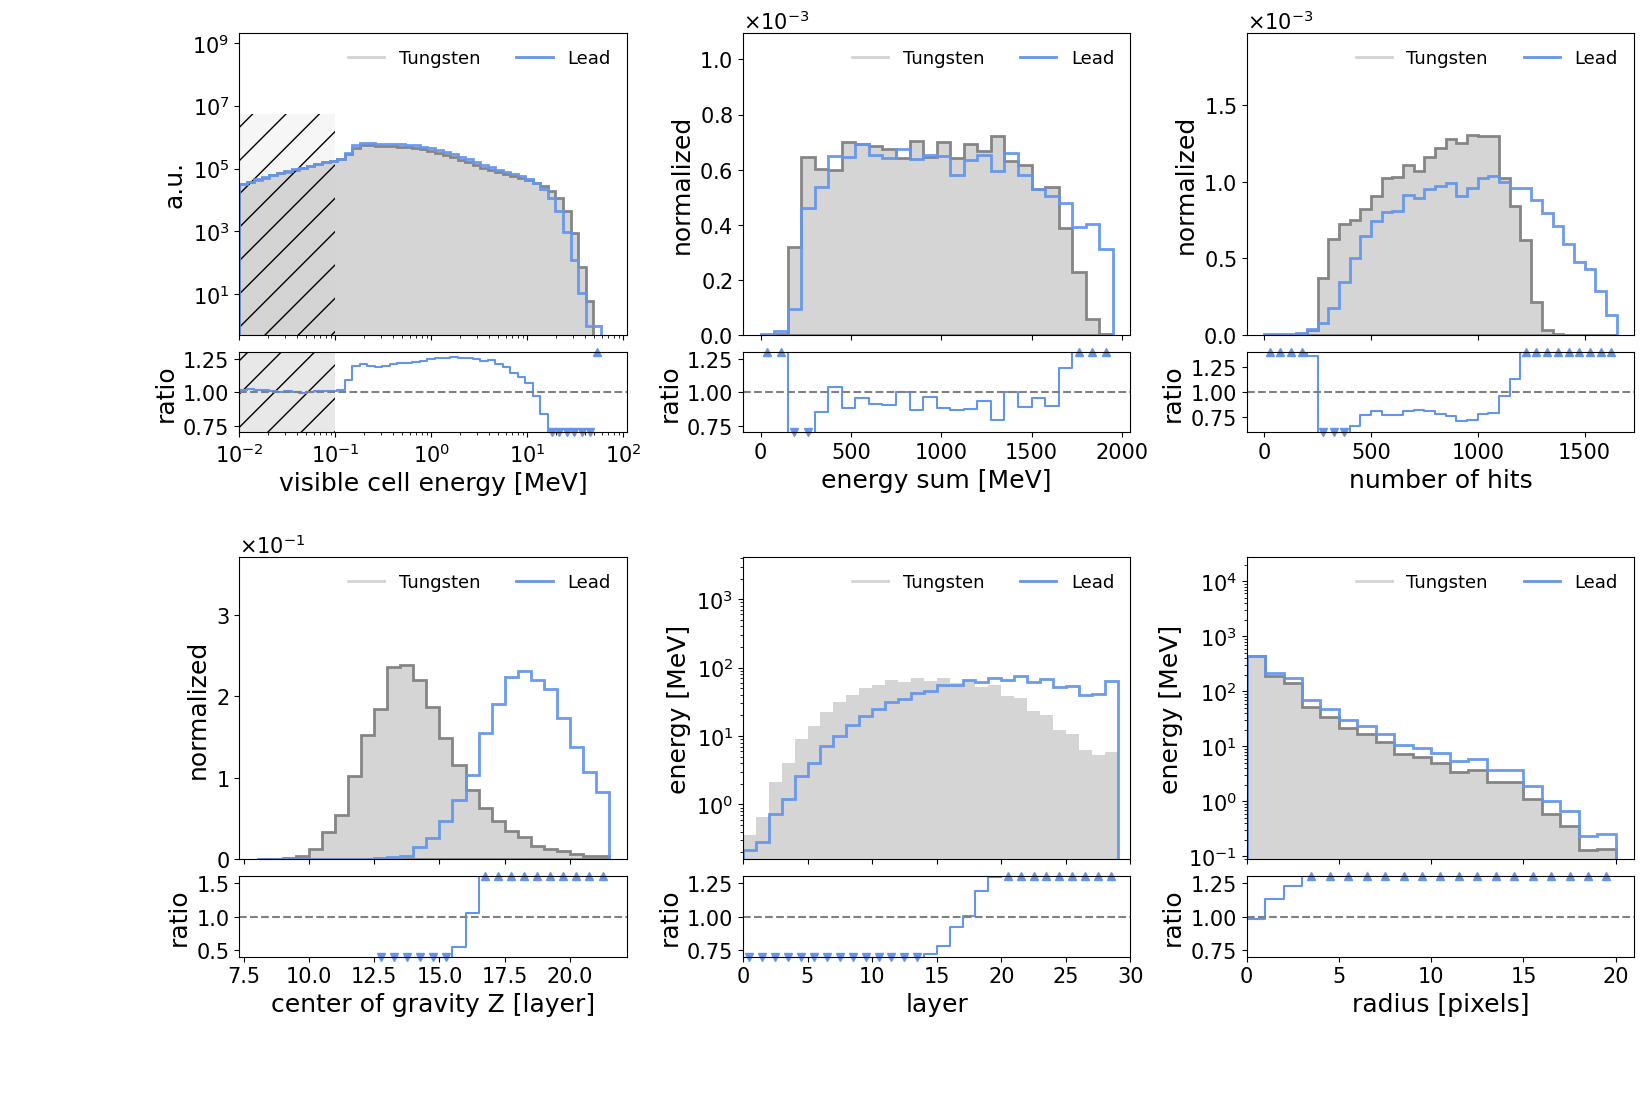

In [7]:
fig = plot_paper_plots(
    [G4_W, G4_Pb],
    labels=["Tungsten", "Lead"],
    colors=["lightgrey", "cornflowerblue"]
)

In [8]:
data_path = "data/PlottingFiles/Ta/photon-shower-3_corrected.hdf5"
G4_Ta = read_shower_file(data_path)

(9640, 30, 30, 30)
(9640, 1)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (1000, 30, 30, 30)
table (640, 30, 30, 30)


In [29]:
len(generated[0]['x']),len(ground_truth[0]['x'])

(446, 401)

In [23]:
np.mean(ground_truth[0]['energy'])

0.6487396057608694

In [22]:
np.mean(generated[0]['energy'])

4.619238273268542

In [33]:
with h5py.File(file_path,"r") as h5file:
    showers = h5file['showers'][()]

In [38]:
showers[10][2]

array([    0, 10513,  9408,  9143,  3277,  6719, 21251,  4394,  6851,
        6681,  6474,  6169,  6286,  6006,  6015,  5890,  5699,  5492,
        5241,  5119, 20027,  6499,  4049,  3982,  5636,  5417,  5349,
        5274,  5156,  3371,  6023,  5929,  5508,  5128,  3345, 23891,
       24459,   293,  3075,  3039,  3022,  3017,  3001,  2947,  2906,
        2823,  2793,  2777,  2705, 10439,  1659,  1529,  1513, 18820,
        2512,  1870,  6026,  8645, 18855, 23629,  1422,  9373,  1697,
        1687,  1685, 23627, 18358,  2533,  1337, 12263,  1551,  1526,
        7992,  1334, 16904, 24015,  1635,  1629,  1621,  2777,  1483,
        1499,  1494, 12018, 10912, 16928,  1518,  1572, 12233,  1530,
        1521,  1509, 18694,   934, 23127,  9099, 15947,  1520,  1518,
       17025,  8642,  1524,  1513,  1503, 12667,  1072,  1071,  1069,
        1063, 23686, 14505,  5513,   615,    17,   994,   992, 15132,
        7243, 17461,   994, 16467,  1060,  5932,   971,   966,   956,
        2437,   863,

In [4]:
from dataloader.tokenizer import EnergyTokenizer
from plotting import plot_paper_plots, plot_compare_gen_showers
from gabbro.utils.utils import get_COG_ak


e_max = 25
e_min = 1e-15
e_res = 0.001

tokenizer = EnergyTokenizer(e_max=e_max, e_min=e_min, resolution=e_res)

#file_path = "Generations/Test_384Embed_Epoch7_G4_W_G4_Ta.h5"
#file_path = "Generations/Test_256Embed_Epoch6_G4_W_G4_Ta.h5"
file_path = "Generations/Testingv3.h5"

def decode_hits(tokens, energies, grid_size=30, SOS_token=0, EOS_token=27001,PAD_token=27002,ground_truth=False):
    tokens = np.asarray(tokens)
    energies = np.asarray(energies)
    
    # Remove SOS, EOS or PAD
    pixel_mask_tokens = np.array([PAD_token, SOS_token, EOS_token])
    pixel_mask = ~np.isin(tokens, pixel_mask_tokens)
    mask = pixel_mask # must be valid in both pixel and energy - this is taken care of, see generate() function of GPT.py
    
    tokens = tokens[mask] - 1 # tokens are offset by 1
    energies = energies[mask]
    
    # Convert flat token -> (z, y, x)
    z = tokens // (grid_size * grid_size)
    rem = tokens % (grid_size * grid_size)
    y = rem // grid_size
    x = rem % grid_size

    assert energies.any() != -1

    # Safety check
    if np.any(tokens < 0) or np.any(tokens >= grid_size**3):
        raise ValueError("Decoded token out of [0, grid_size^3). Check token definitions.")

    return z,x,y,energies

        

def read_generated(file_path,tokenizer,material_list=["G4_W","G4_Ta"],num_showers=-1,material="G4_W"):
    with h5py.File(file_path,"r") as h5file:
        showers = h5file['showers'][()]

        data_dict = {
            "x": [],
            "y": [],
            "z": [],
            "energy": [],
        }

        data_dict_truth = {
            "x": [],
            "y": [],
            "z": [],
            "energy": []
        }

        if num_showers == -1:
            num_showers = len(showers)
        
        for i,shower in enumerate(showers):
            init_E,spatial,energy,spatial_truth,energy_truth,material_index = shower
            mat = material_list[material_index]
            if mat != material:
                continue
                
            x,y,z,E = decode_hits(spatial,energy)
            xt,yt,zt,Et = decode_hits(spatial_truth,energy_truth)

            if i % 5000 == 0 or i == num_showers:
                print(f"Shower #: {i}/{num_showers}, Material: {mat}")

            E = tokenizer.de_tokenize(E)

            data_dict["z"].append(x)
            data_dict["x"].append(y)
            data_dict["y"].append(z)
            data_dict["energy"].append(E)
            
            data_dict_truth["z"].append(xt)
            data_dict_truth["x"].append(yt)
            data_dict_truth["y"].append(zt)
            data_dict_truth["energy"].append(Et)

            if i == num_showers:
                break;

        ak_array = ak.Array(data_dict)
        ak_array_truth = ak.Array(data_dict_truth)
        return ak_array,ak_array_truth

material = "G4_W"
generated,ground_truth = read_generated(file_path,tokenizer,material=material)

Shower #: 0/9650, Material: G4_W
Shower #: 5000/9650, Material: G4_W


In [6]:
generated[0]

<Record {x: [14, ..., 13], y: [...], ...} type='{x: var * int64, y: var * i...'>

In [7]:
ground_truth[0]

<Record {x: [15, ..., 15], y: [...], ...} type='{x: var * int64, y: var * i...'>

In [8]:
idx = 0
np.array(generated[idx]['energy']).mean(),np.array(ground_truth[idx]['energy']).mean()

(0.6882404386688671, 0.6503107642708347)

In [9]:
g_tokens = [generated[i]['energy'] for i in range(len(generated))]
gt_tokens = [ground_truth[i]['energy'] for i in range(len(ground_truth))]

g_tokens = np.concatenate(g_tokens)
gt_tokens = np.concatenate(gt_tokens)

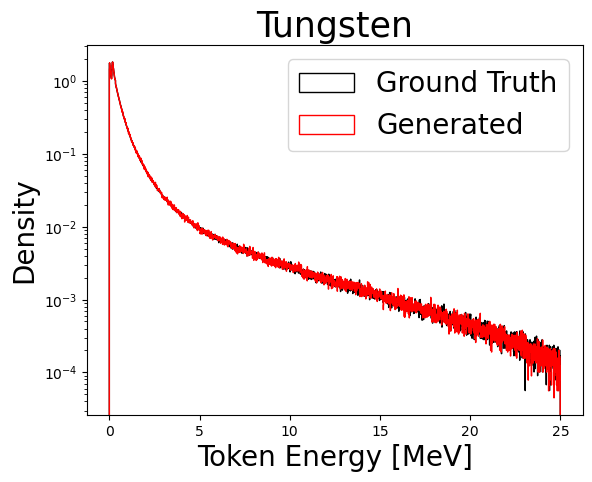

In [10]:
bins = np.arange(1e-15,25 - 1e-15, 0.01)
plt.hist(gt_tokens,bins=bins,density=True,histtype='step',color='black',label='Ground Truth')
plt.hist(g_tokens,bins=bins,density=True,histtype='step',color='red',label='Generated')
plt.xlabel("Token Energy [MeV]",fontsize=20)
plt.ylabel('Density',fontsize=20)
plt.yscale('log')
plt.title("Tungsten",fontsize=25)
plt.legend(fontsize=20)
plt.show()

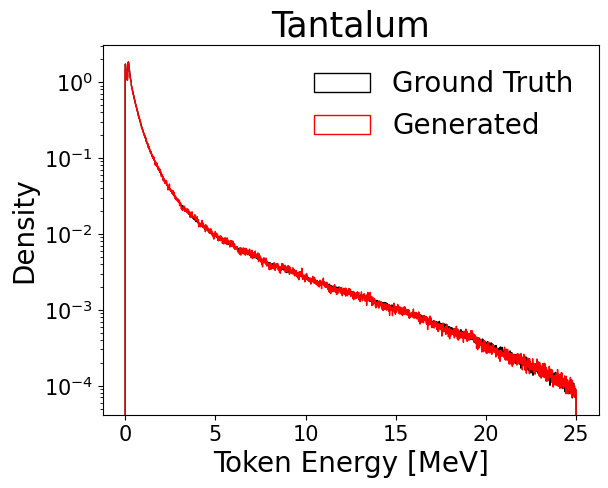

In [11]:
bins = np.arange(1e-15,25 - 1e-15, 0.01)
plt.hist(gt_tokens,bins=bins,density=True,histtype='step',color='black',label='Ground Truth')
plt.hist(g_tokens,bins=bins,density=True,histtype='step',color='red',label='Generated')
plt.xlabel("Token Energy [MeV]",fontsize=20)
plt.ylabel('Density',fontsize=20)
plt.yscale('log')
plt.title("Tantalum",fontsize=25)
plt.legend(fontsize=20)
plt.show()

Tantalum


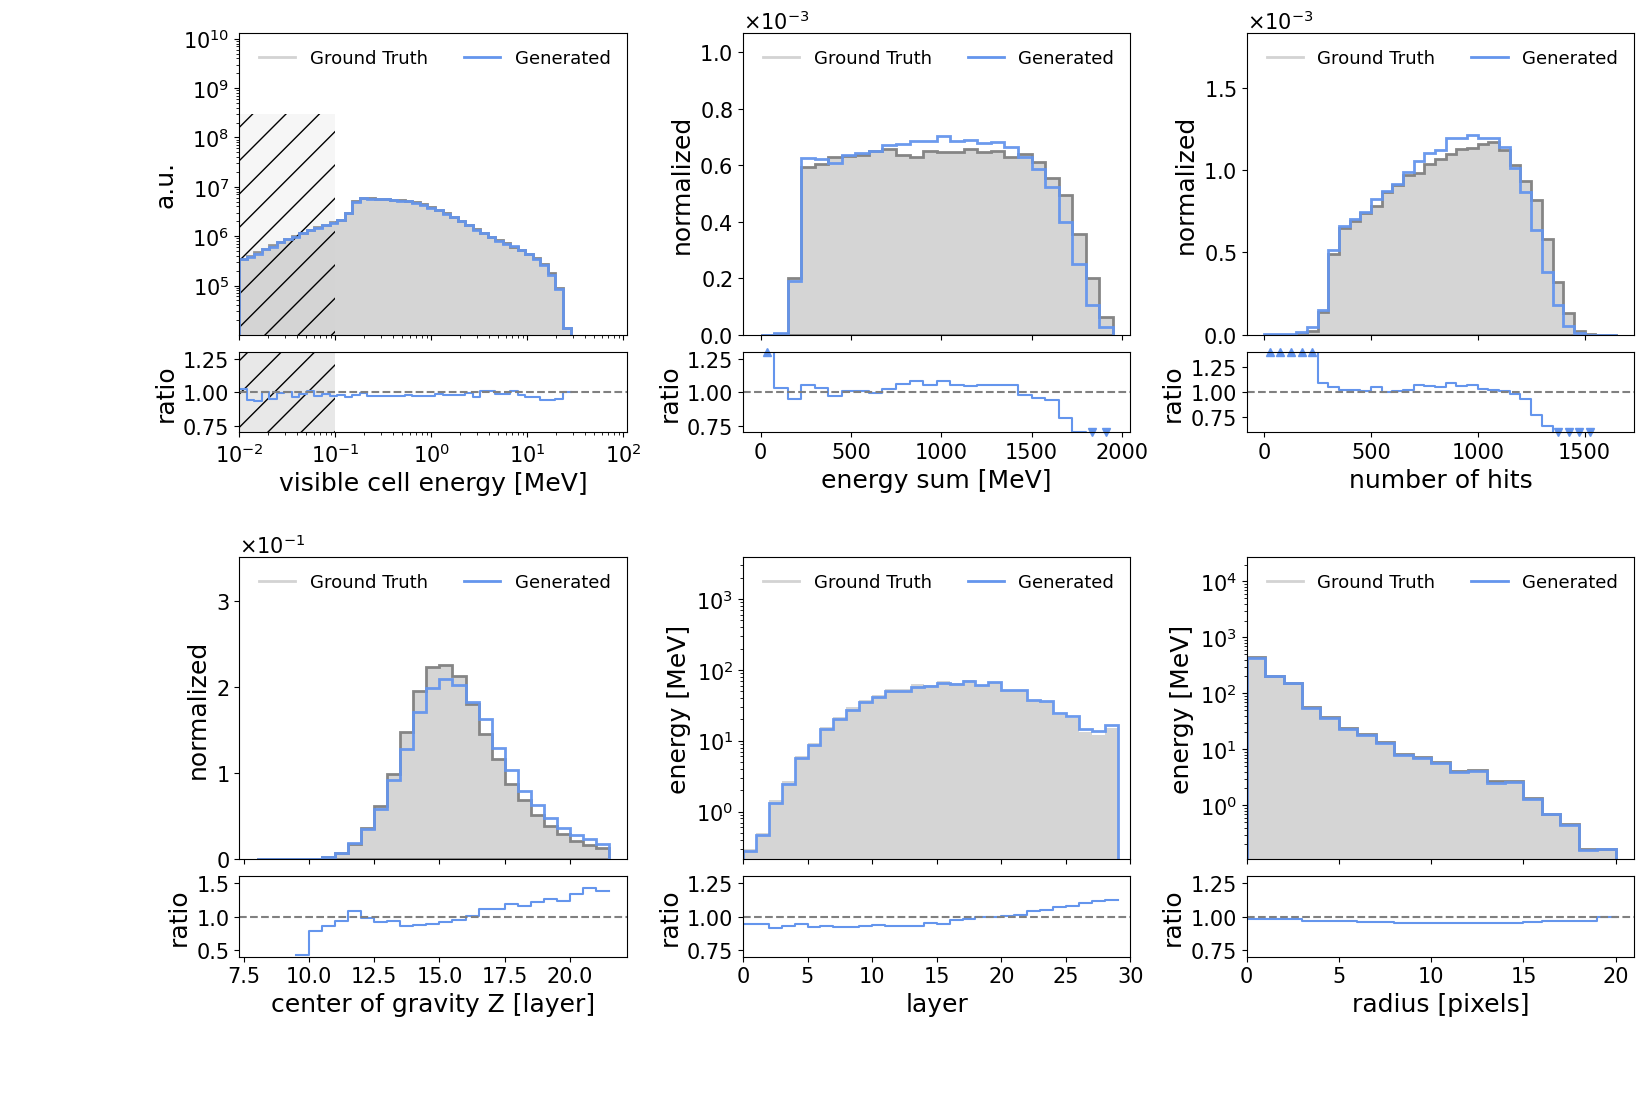

In [12]:
print("Tantalum")
fig = plot_paper_plots(
    [ground_truth, generated],
    labels=["Ground Truth", "Generated"],
    colors=["lightgrey", "cornflowerblue"]
)

Tungsten


/home/james/miniconda3/envs/rapids-24.06/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:246: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/mnt/c/Users/James/FM4Design/FM4CAL/gabbro/plotting/utils.py:528: RuntimeWarning: divide by zero encountered in scalar divide
  ratios.append(counts2[j] / counts1[j])


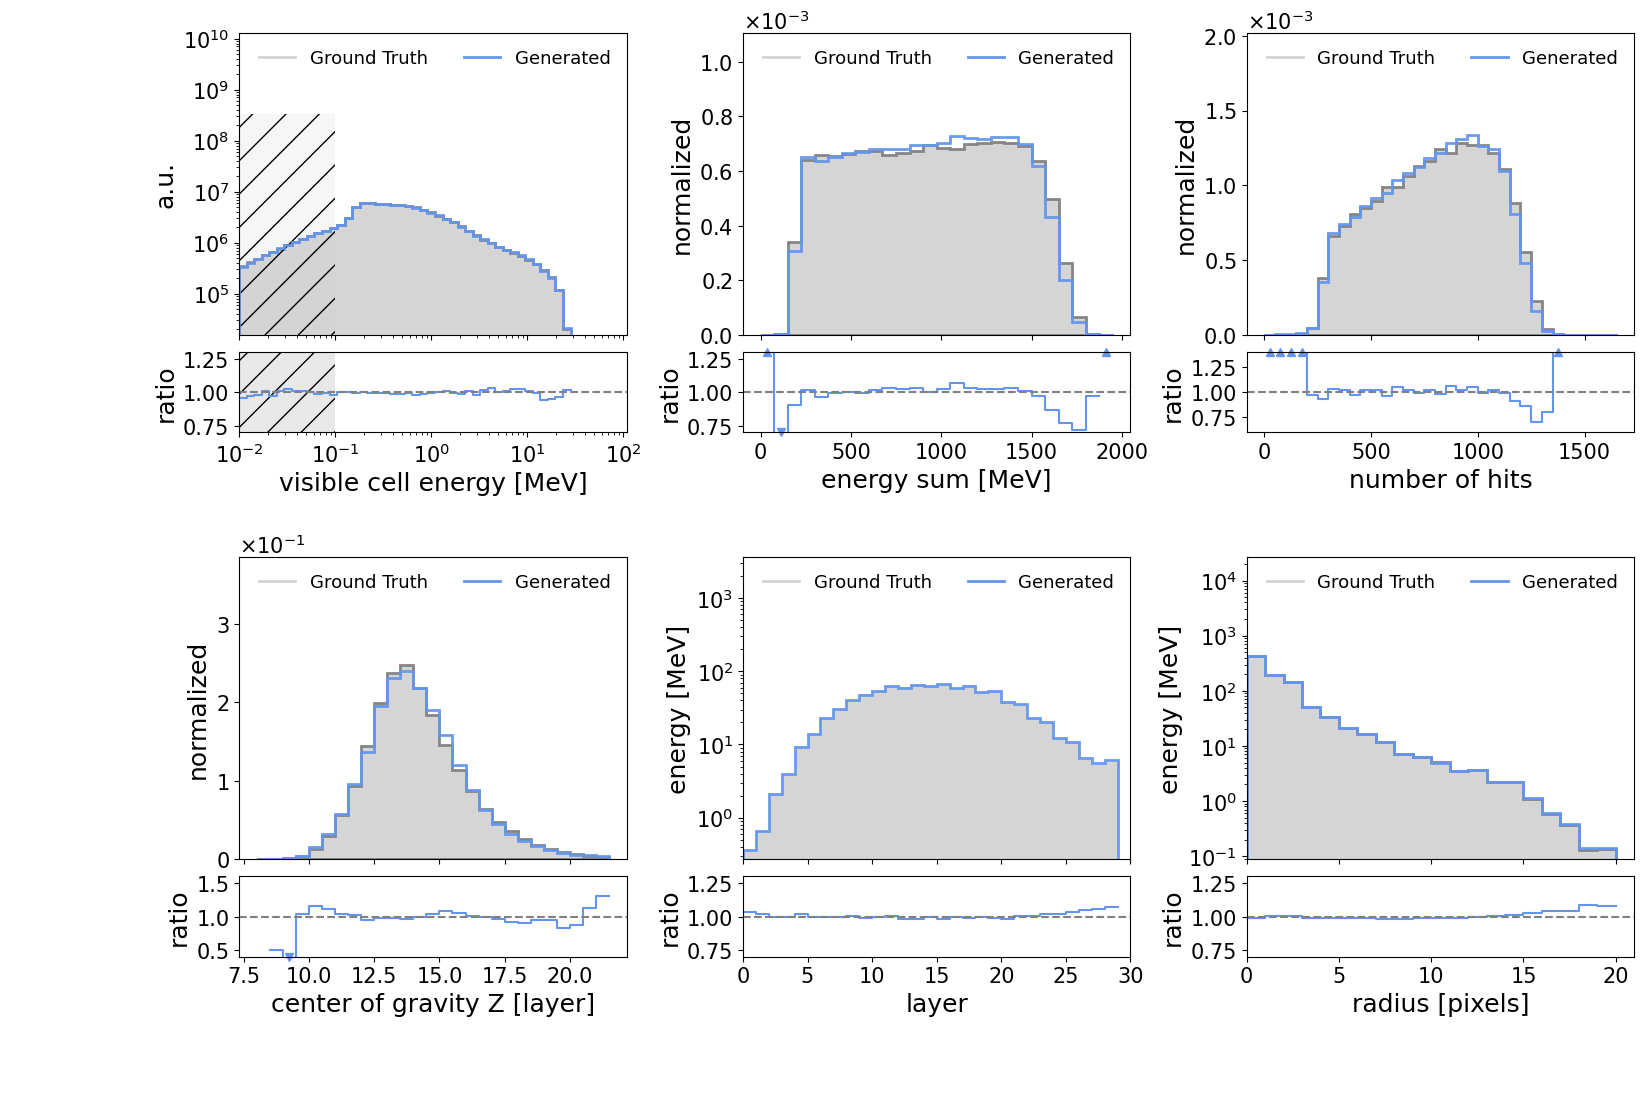

In [7]:
print("Tungsten")
fig = plot_paper_plots(
    [ground_truth, generated],
    labels=["Ground Truth", "Generated"],
    colors=["lightgrey", "cornflowerblue"]
)

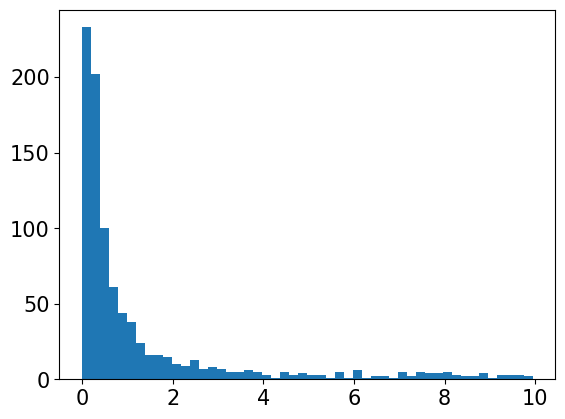

In [198]:
plt.hist(generated[-1]['energy'],bins=50)
plt.show()

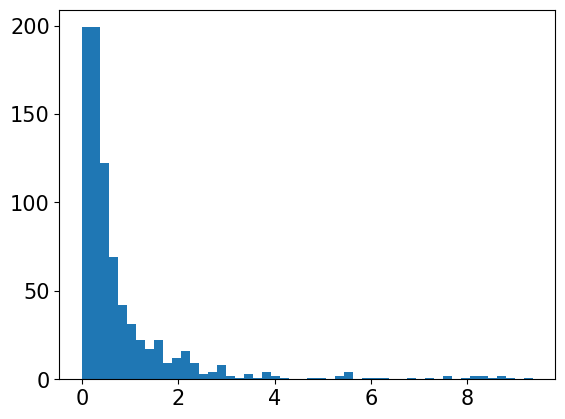

In [199]:
plt.hist(ground_truth[-1]['energy'],bins=50)
plt.show()

In [62]:
es = []
for i in range(len(ground_truth)):
    es.append(ground_truth[i]['energy'])

In [63]:
es = np.array(np.concatenate(es))

In [70]:
es.max()

42.75564696958271

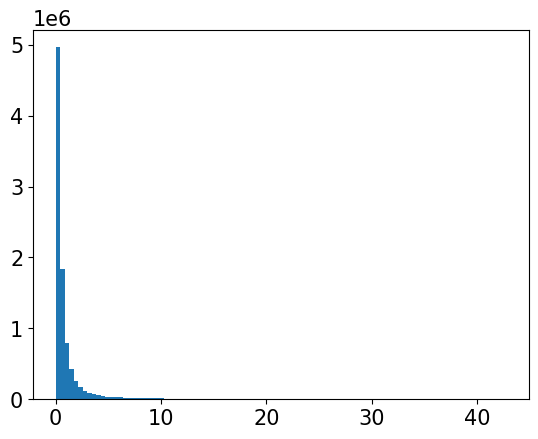

In [69]:
plt.hist(es,bins=100)
plt.show()

In [92]:
def read_shower_file(filepath, n_load=None, chunk_size=1000):
    with h5py.File(filepath, "r") as h5file:
        keys = h5file.keys()

        energy = [] 
        
        for i,key in enumerate(keys):
            group = h5file[key]
            #indices = group["indices"][()]
            values = group["values"][()]

            energy.append(values)

            if i == n_load:
                break
        

    return np.concatenate(energy)

In [97]:
import os

base_dir = "data/W_Simulation"
W_Files = os.listdir(base_dir)
W_energies = []

for file in W_Files:
    e = read_shower_file(os.path.join(base_dir,file),n_load=-1)
    W_energies.append(e)


W_energies = np.concatenate(W_energies)

In [98]:
print(W_energies.shape)

(904952861,)


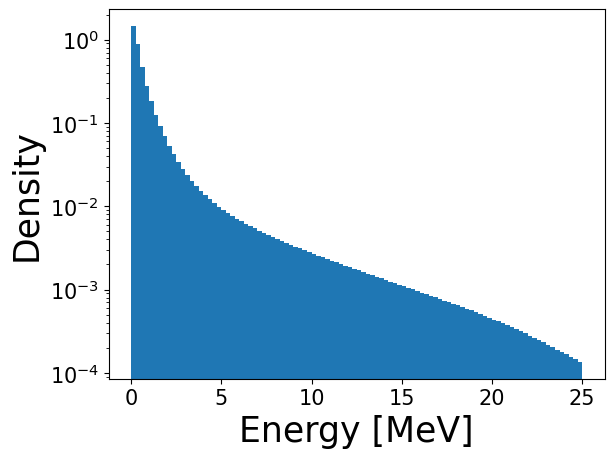

In [205]:
plt.hist(W_energies,bins=100,range=[0,25],density=True)
plt.yscale('log')
plt.xlabel("Energy [MeV]",fontsize=25)
plt.ylabel("Density",fontsize=25)
plt.show()

In [101]:
print("W Max: ", W_energies.max())
print("W Mean: ",W_energies.mean())

W Max:  87.27755
W Mean:  1.0254247


In [105]:
import os

base_dir = "data/Ta_Simulation"
Ta_Files = os.listdir(base_dir)
Ta_energies = []

for file in Ta_Files:
    print("Reading: ",os.path.join(base_dir,file))
    e = read_shower_file(os.path.join(base_dir,file),n_load=-1)
    Ta_energies.append(e)


Ta_energies = np.concatenate(Ta_energies)

Reading:  data/Ta_Simulation/photon-shower-0_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-10_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-11_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-12_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-13_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-14_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-15_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-16_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-17_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-18_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-19_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-1_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-20_corrected_compressed.hdf5
Reading:  data/Ta_Simulation/photon-shower-21_corrected_compressed

Ta Max:  108.603546
Ta Mean:  0.99790007


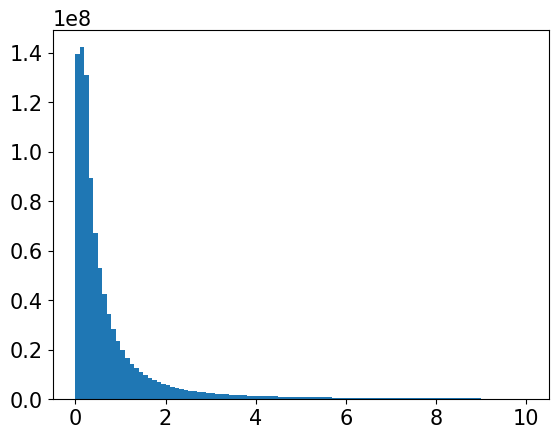

In [109]:
print("Ta Max: ", Ta_energies.max())
print("Ta Mean: ",Ta_energies.mean())

plt.hist(Ta_energies,bins=100,range=[0,10])
plt.show()

In [110]:
import os

base_dir = "data/Pb_Simulation"
Pb_Files = os.listdir(base_dir)
Pb_energies = []

for file in Pb_Files:
    print("Reading: ",os.path.join(base_dir,file))
    e = read_shower_file(os.path.join(base_dir,file),n_load=-1)
    Pb_energies.append(e)


Pb_energies = np.concatenate(Pb_energies)

Reading:  data/Pb_Simulation/photon-shower-0_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-10_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-11_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-12_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-13_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-14_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-15_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-16_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-17_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-18_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-19_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-1_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-20_corrected_compressed.hdf5
Reading:  data/Pb_Simulation/photon-shower-21_corrected_compressed

Pb Max:  113.79462
Pb Mean:  0.9822448


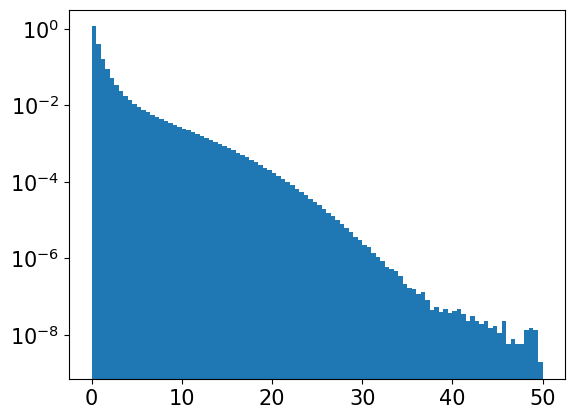

In [160]:
print("Pb Max: ", Pb_energies.max())
print("Pb Mean: ",Pb_energies.mean())

plt.hist(Pb_energies,bins=100,range=[0,50],density=True)
plt.yscale('log')
plt.show()

In [20]:
import numpy as np

class EnergyTokenizer():
    def __init__(self, e_max=25.0, e_min=1e-15, resolution=0.001):
        super().__init__()
        self.e_max = e_max
        self.e_min = e_min
        self.energy_res = resolution
        self.e_bins = np.arange(self.e_min,
                                self.e_max + self.energy_res,
                                self.energy_res)

    def tokenize(self, energies):
        """
        Supports tokenization of both dense and sparse array representations

        - Dense Input: np.ndarray of shape (30, 30, 30)
        - Sparse input: tuple of (indices, values)

        Returns:
        - Energy tokens [1, 25000] from np.digitize()
        """
        # Sparse tuple input: only tokenize the energy values
        if isinstance(energies, tuple) and len(energies) == 2:
            indices, values = energies
            return np.digitize(values, self.e_bins)  # [1, 25000]

        # Dense array, (30, 30, 30)
        if isinstance(energies, np.ndarray):
            return np.digitize(energies.flatten(), self.e_bins)  # [1, 25000]

        else:
            raise ValueError("Unsupported input format for tokenization")


    def de_tokenize(self, tokens):
        z = self.e_min + (tokens + 0.5) * self.energy_res
        z = z + np.random.uniform(-0.5 * self.energy_res,
                                  0.5 * self.energy_res,
                                  size=tokens.shape)
        return np.clip(z, self.e_min, self.e_max)


tokenizer = EnergyTokenizer(e_max=25.0,e_min=1e-15)
tokenizer.e_bins.shape



(25001,)

In [28]:
val=25.0 - 1e-15 
tokenizer.tokenize(np.array(val))

array([25001])